<h1 style="color: red; text-align: center;">Practical: Data Analysis & Vectors</h1>
<h2 style="color: red;">Instructor: Dr. Khaled Mohamad</h2>


---

> Instructions: Answer all questions in order. Write clean, commented code. Use Markdown cells for written answers.

---

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Q1. Distance Matrix with NumPy Broadcasting
You have 3 delivery locations (group A) and 2 warehouses (group B), given as 2D coordinates:

In [3]:
A = np.array([[1, 2],
 [4, 6],
 [7, 1]])
B = np.array([[0, 0],
 [5, 5]])


1. Reshape A and B for broadcasting: A_exp = A[:, np.newaxis, :] and B_exp = B[np.newaxis, :, :] . Print both
shapes.
2. Compute the difference diff = A_exp - B_exp . Print its shape.
3. Compute the Euclidean distance matrix using np.sqrt(np.sum(diff**2, axis=2)) . Print the result rounded to 2 decimal
places.
4. In a Markdown cell, answer: which warehouse (B0 or B1) is closer on average to all delivery locations?

In [4]:
# 1
A_exp = A[:, np.newaxis, :]
B_exp = B[np.newaxis, :, :]

print("A_exp shape: ", A_exp.shape)
print("B_exp shape: ", B_exp.shape)

A_exp shape:  (3, 1, 2)
B_exp shape:  (1, 2, 2)


In [5]:
# 2
diff = A_exp - B_exp
print(diff.shape)

(3, 2, 2)


In [6]:
# 3
eucl_dist = np.sqrt(np.sum(diff**2, axis=2))

print(eucl_dist.round(2))

[[2.24 5.  ]
 [7.21 1.41]
 [7.07 4.47]]


In [7]:
# 4
avg_dist = eucl_dist.mean(axis=0)

print("Average dist:", avg_dist)

Average dist: [5.50607945 3.62878317]


---

# Q2. Given:

In [8]:
p = [2, 1, -3]
q = [4, -2, 1]

1. Compute p · q using four different methods (loop, np.dot , np.multiply + sum , np.matmul ).
2. Using the geometric formula p · q = ||p|| × ||q|| × cos(θ) , compute the angle θ between p and q in both
radians and degrees.
3. Interpret the angle: are the vectors more aligned, perpendicular, or opposing?
4. Now create a vector r that is guaranteed to be orthogonal to p (dot product = 0) in 3D. Verify it numerically.
   
**ANSWER**

In [9]:
# 1
v1 = 0
for i, j in zip(p, q):
    v1 += i * j
print(v1)

3


In [10]:
v2 = np.dot(p, q)
print(v2)

3


In [11]:
v3 = np.sum(np.multiply(q, p))
print(v3)

3


In [12]:
v4 = np.matmul(p, q)
print(v4)

3


In [13]:
# 2
norm_p = np.linalg.norm(p)
norm_q = np.linalg.norm(q)

cos_theta = v2 / (norm_q * norm_p)
theta_rad = np.arccos(cos_theta)
theta_degree = np.degrees(theta_rad)
print(theta_degree)

79.92346287144585


3. Anglse is almost 80 degrees. They're almokst perpendiculat but slightly aligned since dot product > 0

In [14]:
# 4
r = np.array([1, 1, 1])

print(np.dot(p, r))

0


---

## Q3. Given vectors:

1. Compute the magnitudes of u and v . What is the ratio ||v|| / ||u|| ? What does this ratio tell you?
2. Compute the unit vectors of u and v . What do you notice?
3. Are u and v parallel? Justify your answer mathematically (do not just plot — use the dot product and magnitudes).
4. On a single plot, draw u , v , and the unit vector of u . Add a legend and dashed axes.
   
**ANSWER**

In [15]:
u = [3, -4]
v = [-6, 8]

In [16]:
# 1
norm_u = np.linalg.norm(u)
norm_v = np.linalg.norm(v)
print("||u|| = ", norm_u)
print("||v|| = ", norm_v)

ratio = norm_v / norm_u
print("Ratio: ", ratio)

||u|| =  5.0
||v|| =  10.0
Ratio:  2.0


v is the scaled version of u(twice)

In [17]:
# 2
unit_u = u / norm_u
unit_v = v / norm_v
print(unit_v, unit_u)

[-0.6  0.8] [ 0.6 -0.8]


their unit vectors are in opposite direction

In [18]:
# 3
dot = np.dot(u, v)
print("Dot product u·v =", dot)
print("||u|| * ||v|| =", norm_u * norm_v)

Dot product u·v = -50
||u|| * ||v|| = 50.0


Parallel but opposite direction.

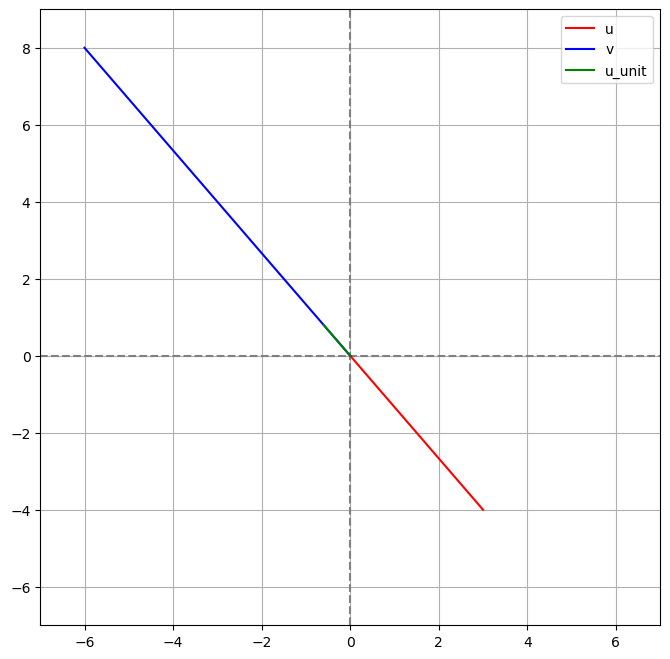

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

# axises
plt.axhline(0, linestyle='--', color='gray')
plt.axvline(0, linestyle='--', color='gray')

# u
plt.plot([0, u[0]], [0, u[1]], 'r-', label='u')

# v
plt.plot([0, v[0]], [0, v[1]], 'b-', label='v')

# unit_v
plt.plot([0, unit_v[0]], [0, unit_v[1]], 'g-', label='u_unit')

plt.xlim(-7,7)
plt.ylim(-7,9)

plt.legend()
plt.grid()
plt.show()

---

## Q4. Pandas: Load, Explore & Clean
Load the MPG dataset (car fuel efficiency), a dataset built into Seaborn:

Each row is a car model. Key columns: mpg (miles per gallon), cylinders , weight , horsepower , origin , name .

1. Print the shape and display the first 5 rows.
2. Print the number of missing values per column. Which column has missing values?
3. Create df_clean by dropping rows with any missing values using .dropna() . Print the new shape.
4. Print basic summary statistics using .describe() . What is the average mpg ?
   
**ANSWER**

In [20]:
df = sns.load_dataset('mpg')

In [21]:
# 1
print(df.shape)
df.head()

(398, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


In [22]:
# 2
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64

horse power has missing value

In [23]:
# 3
df_clean = df.dropna()

print(df_clean.shape)

(392, 9)


In [24]:
#4
df_clean.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
count,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000,392.000000
mean,23.445918,5.471939,194.411990,104.469388,2977.584184,15.541327,75.979592
std,7.805007,1.705783,104.644004,38.491160,849.402560,2.758864,3.683737
min,9.000000,3.000000,68.000000,46.000000,1613.000000,8.000000,70.000000
25%,17.000000,4.000000,105.000000,75.000000,2225.250000,13.775000,73.000000
50%,22.750000,4.000000,151.000000,93.500000,2803.500000,15.500000,76.000000
75%,29.000000,8.000000,275.750000,126.000000,3614.750000,17.025000,79.000000
max,46.600000,8.000000,455.000000,230.000000,5140.000000,24.800000,82.000000


Avg mpg - 23.45

## Q5. Filtering, Sorting & GroupBy
Using df_clean from Q2:
1. Filter cars with mpg > 30 (fuel-efficient cars). Print how many there are.
2. Sort the dataset by mpg in descending order and display the top 5 most fuel-efficient cars — show only the columns name ,
mpg , cylinders , origin .
3. Use GroupBy to find the average mpg per country of origin ( origin ). Print the result.
4. In one Markdown sentence, state which country produces the most fuel-efficient cars on average.

**ANSWER**

In [25]:
# 1
efficient = df_clean[df_clean['mpg'] > 30]
print(len(efficient))

83


In [26]:
# 2
efficient = efficient.sort_values(by=["mpg"], ascending=[False])

efficient[['name','mpg','cylinders','origin']].head()

,name,mpg,cylinders,origin
322,mazda glc,46.6,4,japan
329,honda civic 1500 gl,44.6,4,japan
325,vw rabbit c (diesel),44.3,4,europe
394,vw pickup,44.0,4,europe
326,vw dasher (diesel),43.4,4,europe


In [27]:
# 3
avg_mpg_origin = df_clean.groupby('origin')['mpg'].mean()
print(avg_mpg_origin)

origin
europe    27.602941
japan     30.450633
usa       20.033469
Name: mpg, dtype: float64


4. On average Japan produces the most fuel efficient cars

---

## Q6. Visualization
Using df_clean , create a figure with two subplots side by side ( figsize=(12, 4) ):

- Left subplot: A bar plot of average mpg per origin . Title: 'Average MPG by Country' . Add a y-axis label 'MPG' .
- Right subplot: A scatter plot of weight (x-axis) vs mpg (y-axis). Title: 'MPG vs Car Weight' . Add axis labels.

Use plt.tight_layout() and plt.show() . In a Markdown cell, write one observation from the scatter plot.

**ANSWER**

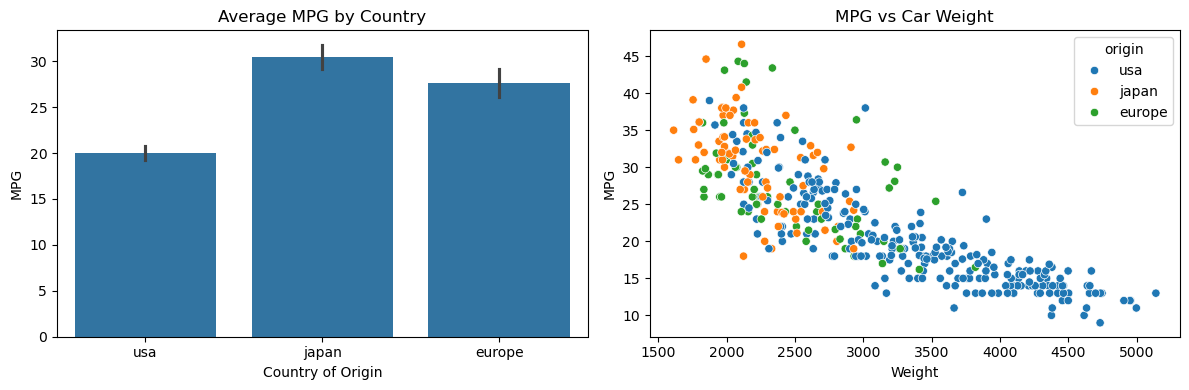

In [28]:
plt.figure(figsize=(12, 4))

plt.subplot(1,2,1)
sns.barplot(data=df_clean, x='origin', y='mpg') 
plt.ylabel('MPG')
plt.xlabel('Country of Origin')
plt.title('Average MPG by Country')

plt.subplot(1,2,2)
sns.scatterplot(x='weight', y='mpg', data=df_clean, hue='origin')
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.title('MPG vs Car Weight')

plt.tight_layout()
plt.show()

From bar plot - Japanese cars are the most fuel-efficient with an average exceeding 30 MPG, while American models show the lowest efficiency at approximately 20 MPG.

From scatter we can see that almost every car with bigger weight has lower mpg. So weight and mpg has a strong negative correlation

## Q7. KNN Classification on the Wine Dataset
The Wine dataset contains chemical measurements of wines from 3 different cultivars (classes 0, 1, 2). It is loaded from sklearn.
1. Load the dataset and print feature_names , target_names , and the shape of the data. 
2. Split into train/test sets (75% train, 25% test) using random_state=42 .
3. Train a KNeighborsClassifier with n_neighbors=5 . Print the test accuracy.
4. In a Markdown cell, state in one sentence whether this is a classification or regression problem and why.

**ANSWER**

In [29]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# 1
data = load_wine()
X = data.data
y = data.target

print("Feature names:", data.feature_names)
print("Target names:", data.target_names)
print("Data shape:", X.shape)

Feature names: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Target names: ['class_0' 'class_1' 'class_2']
Data shape: (178, 13)


In [30]:
# 2

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [31]:
# 3
model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Test accuracy:", accuracy)

Test accuracy: 0.7111111111111111


4. This is a classification problem, because the target is discrete classes (0,1,2).